In [196]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [197]:
from llm_unsupervised_conf.plots import METHODS_MAP, METHODS_MAP_SHORT, DATASETS_MAP

In [206]:
def double_plot_avg_and_worstcase_by_method(
    df: pd.DataFrame,
    metrics=("ECE", "Brier", "AUROC"),
    method_col="Method",
    agg_for_worst=None,
    method_order=None,
    figsize=(13, 5),
    title_prefix="",
    show_values=False,
    plt_save_key=None,
):
    if agg_for_worst is None:
        agg_for_worst = {}

    default_worst = {}
    for m in metrics:
        ml = m.lower()
        if ("ece" in ml) or ("mce" in ml) or ("brier" in ml) or ("nll" in ml) or ("loss" in ml):
            default_worst[m] = "max"
        else:
            default_worst[m] = "min"

    for m in metrics:
        if m not in df.columns:
            raise ValueError(f"Missing metric column '{m}' in df.")
    if method_col not in df.columns:
        raise ValueError(f"Missing method column '{method_col}' in df.")

    methods = method_order if method_order is not None else sorted(df[method_col].unique().tolist())

    avg = df.groupby(method_col)[list(metrics)].mean().reindex(methods)

    worst = pd.DataFrame(index=methods, columns=list(metrics), dtype=float)
    for m in metrics:
        how = agg_for_worst.get(m, default_worst[m])
        if how == "max":
            worst[m] = df.groupby(method_col)[m].max().reindex(methods)
        elif how == "min":
            worst[m] = df.groupby(method_col)[m].min().reindex(methods)
        else:
            raise ValueError(f"agg_for_worst[{m}] must be 'max' or 'min', got {how!r}")

    # one style per method
    method_styles = {
        methods[0]: dict(color=pal[0], hatch=None),
        methods[1]: dict(color=pal[1], hatch=None),
        methods[2]: dict(color=pal[2], hatch=None),
        methods[3]: dict(color=pal[3], hatch=None),
        methods[4]: dict(color=pal[4], hatch="x"),
    }

    def _plot_table(table: pd.DataFrame, axes, top=False):
        if len(metrics) == 1:
            axes = [axes]

        for ax, m in zip(axes, metrics):
            y = table[m].astype(float).values
            x = np.arange(len(methods))

            for i, method in enumerate(methods):
                style = method_styles[method]
                ax.bar(
                    x[i],
                    y[i],
                    color=style["color"],
                    hatch=style["hatch"],
                )

            arrow = "↓"
            if m == "AUROC":
                arrow = "↑"
            ax.set_ylim(None, np.max(y) * 1.17)
            ax.set_title(f"{m} ({arrow})" if top else "")
            ax.set_xticks([])   # remove xticks everywhere
            ax.grid(axis="y", alpha=0.3)

            if show_values:
                for xi, yi in zip(x, y):
                    if np.isfinite(yi):
                        ax.text(xi, yi, f"{yi:.2f}", ha="center", va="bottom", fontsize=10)

    fig, axes = plt.subplots(2, len(metrics), sharex=True, figsize=figsize)

    axes[0, 0].set_ylabel("Average", fontsize=14, fontweight="bold")
    axes[1, 0].set_ylabel("Worst", fontsize=14, fontweight="bold")

    _plot_table(avg, axes[0, :], top=True)
    _plot_table(worst, axes[1, :], top=False)

    # custom legend handles
    legend_handles = [
        Patch(
            facecolor=method_styles[m]["color"],
            hatch=method_styles[m]["hatch"],
            label=METHODS_MAP_SHORT.get(m, m),
        )
        for m in methods
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(methods),
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, -0.01),
    )

    fig.tight_layout(rect=[0, 0.08, 1, 1])  # leave space for bottom legend

    if plt_save_key is not None:
        plt_save_path = f"../plots/{plt_save_key}_avg_and_worst.png"
        plt.savefig(plt_save_path, dpi=600, bbox_inches="tight")

    plt.show()

In [240]:
def analyze_exps(
    models, 
    datasets, 
    exp_key="all",
    plt_title=None,
    main_only=False,
    show_models=True,
    show_datasets=True,
    show_qwen=True,
    save_plots=True
):

    full_df = pd.read_csv(f"../results/cal_exp_results_{exp_key}.csv")
    full_df = full_df[(full_df["Model"].isin(models)) & (full_df["Dataset"].isin(datasets))]

    # display(full_df.head(5))

    show_cols = ["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]
    
    print("AVERAGE")
    display(
        full_df[show_cols].groupby(["Method"]).mean().sort_values(["ECE2"])
    )
    print("WORST")
    grouped_df = full_df[show_cols+["Model", "Dataset"]].groupby(["Model", "Dataset", "Method"]).mean().reset_index()
    display(
        grouped_df[show_cols[:-1]].groupby(["Method"]).max().sort_values(["ECE2"])
    )

    if plt_title is not None and plt_title != "":
        plt_title += " - "

    if save_plots:
        plt_save_key = exp_key
    else:
        plt_save_key = None

    double_plot_avg_and_worstcase_by_method(
        grouped_df,
        metrics=("ECE1", "ECE2", "MCE", "Brier", "AUROC"),
        method_order=["logprob", "ans_logprob", "verbal_conf", OUR_METHOD, "oracle_sc"],
        show_values=True,
        figsize=(13,3.25),
        title_prefix=plt_title,
        plt_save_key=plt_save_key
    )

    if main_only:
        return

    if show_datasets:

        print("----"*10)
        print("--* Dataset comparison *--")
        print("----"*10)
    
        plot_method_comparisons(
            full_df,
            metrics=["ECE2", "Brier", "AUROC"],
            facet="Dataset",
            dataset_order=datasets,   # optional: order + subset
            model_order=None,                              # None => include all models
            method_order=["logprob", "ans_logprob", "verbal_conf", OUR_METHOD],
            sharey=None,
            plt_title="Results by dataset"
        )
    
        for dataset in datasets:
            print(dataset)
            dataset_df = full_df[(full_df["Dataset"] == dataset)]
            display(
                dataset_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean()
            )

    if show_models:

        print("----"*10)
        print("--* Model comparison *--")
        print("----"*10)

        for model in models:
            print(model)
            model_df = full_df[(full_df["Model"] == model)]
            display(
                model_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean()
            )
    if show_qwen:
    
        qwen_models = [
            "Qwen/Qwen3-0.6B", 
            "Qwen/Qwen3-1.7B", 
            "Qwen/Qwen3-4B-Thinking-2507", 
            "Qwen/Qwen3-8B",
        ]
    
        for qm in qwen_models:
            if qm not in models:
                return
    
        model_size_ticks = [0.6, 1.7, 4, 8]
    
        if "Qwen/Qwen3-14B" in models:
            qwen_models.append("Qwen/Qwen3-14B")
            model_size_ticks.append(14)
        
        metrics = ["ECE2", "Brier"]
        method_order=[
            "logprob", "ans_logprob", "verbal_conf", 
            OUR_METHOD, 
            "oracle_sc"
        ]
        
        fig, axs = plt.subplots(1,2, figsize=(10,3))
    
        for idx, metric in enumerate(metrics):
        
            ax = axs[idx]
        
            X_method = {m:[] for m in method_order}
            
            for model in qwen_models:
                model_df = full_df[(full_df["Model"] == model)]
                mean_df = model_df[["Method"]+[metric]].groupby(["Method"]).mean()
                for m in method_order:
                    row = mean_df.loc[m]
                    X_method[m].append(row[metric])
        
            for m in method_order:
                ax.plot(model_size_ticks, X_method[m], "--o", label=METHODS_MAP[m])
        
            ax.set_ylabel(metric)
            ax.set_xlabel("Parameters (Billions)")
            
        axs[-1].legend()

        fig.tight_layout()
        plt.savefig("../plots/qwen_scaling.png", dpi=600, bbox_inches="tight")
        
        plt.show()
        
    
        metric = "ECE2"
        method_order=[
            "logprob", "ans_logprob", "verbal_conf", OUR_METHOD
        ]
        
        fig, axs = plt.subplots(
            1, 
            len(qwen_models), 
            figsize=(13, 2.5), 
            constrained_layout=True,
            sharey="row"
        )
        
        plot_df = full_df[show_cols+["Accuracy", "Model", "Dataset"]].groupby(["Model", "Dataset", "Method"]).mean().reset_index()
        
        for i, model in enumerate(qwen_models):
            ax = axs[i]
        
            for m in method_order:
                method_df = plot_df[(plot_df["Method"] == m) & (plot_df["Model"] == model)]
        
                x = method_df["Accuracy"].to_numpy(dtype=float)
                # x = 1-x
                
                y = method_df[metric].to_numpy(dtype=float)
        
                # scatter (capture the artist so we can reuse its color)
                if m == OUR_METHOD:
                    sc = ax.scatter(x, y, label=METHODS_MAP_SHORT[m], marker="*", s=120)
                else:
                    sc = ax.scatter(x, y, label=METHODS_MAP_SHORT[m])
                color = sc.get_facecolor()[0]  # RGBA of the scatter points
        
                # best-fit line (only if it makes sense)
                if len(x) >= 2 and np.nanstd(x) > 0:
                    # Fit y = a*x + b
                    a, b = np.polyfit(x, y, 1)
        
                    # Draw line across the span of x values in this group
                    xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
                    yy = a * xx + b
                    ax.plot(xx, yy, "--", color=color, linewidth=2, alpha=0.5)
        
            ax.set_title(model.replace("Qwen/", ""), fontsize=14)
            
            ax.set_xlabel("Accuracy", fontsize=14)
            ax.set_xlim(0.18, 1.0)

            # ax.set_xlabel("Pred. Error", fontsize=14)
            # ax.set_xlim(0.0, 0.85)
        
        axs[-1].legend(ncol=2, fontsize=11)
        axs[0].set_ylabel(metric, fontsize=14)
        # fig.tight_layout()
        
        plt.savefig("../plots/sensitivity_to_acc.png", dpi=600, bbox_inches="tight")
        plt.show()

        return full_df
        

In [241]:
OUR_METHOD = "split_isotonic_on_ridge_nrt"

AVERAGE


,ECE1,ECE2,MCE,Brier,AUROC
Method,,,,,
logprob_scaled,0.052899,0.065568,0.133692,0.160519,0.653098
ans_logprob_scaled,0.055892,0.069104,0.142323,0.159773,0.620659
question_only_split_isotonic_on_ridge_nrt,0.065318,0.077732,0.173808,0.164071,0.635141
question_only_split_isotonic_on_ridge,0.068021,0.082267,0.184936,0.164443,0.640340
split_isotonic_on_ridge,0.068940,0.086282,0.200956,0.154973,0.710962
split_isotonic_on_ridge_nrt,0.069416,0.086301,0.198592,0.155102,0.707654
blackbox_split_isotonic_on_ridge,0.068919,0.086650,0.197148,0.154464,0.712467
blackbox_split_isotonic_on_ridge_nrt,0.069210,0.087227,0.199568,0.154810,0.708505
blackbox_ridge_clip,0.073913,0.092273,0.192251,0.154172,0.718038


WORST


,ECE1,ECE2,MCE,Brier
Method,,,,
logprob_scaled,0.093192,0.110313,0.206200,0.250617
question_only_split_isotonic_on_ridge_nrt,0.118673,0.134373,0.283712,0.256245
question_only_split_isotonic_on_ridge,0.121057,0.148884,0.318479,0.259777
split_isotonic_on_ridge_nrt,0.127420,0.149154,0.300615,0.252351
blackbox_split_isotonic_on_ridge_nrt,0.125943,0.149174,0.300228,0.254589
split_isotonic_on_ridge,0.131588,0.153237,0.303103,0.252895
blackbox_split_isotonic_on_ridge,0.133732,0.157009,0.303664,0.256781
ans_logprob_scaled,0.143229,0.164912,0.290252,0.250265
ridge_clip,0.158069,0.185398,0.388729,0.266428


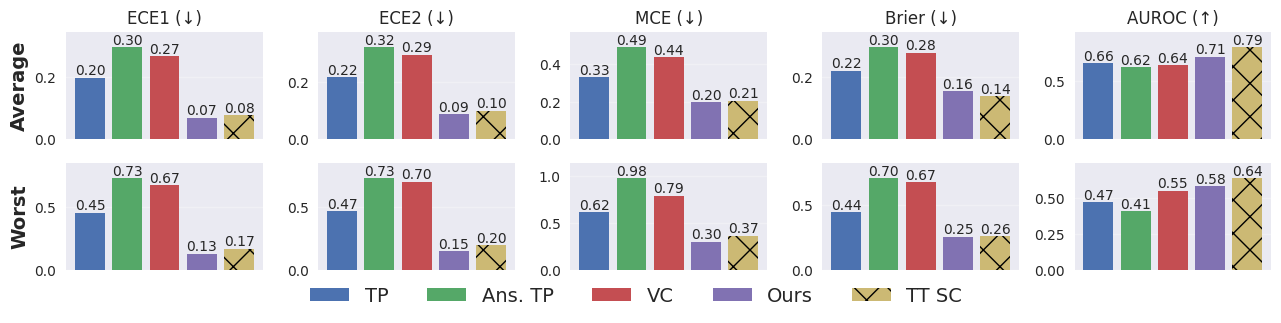

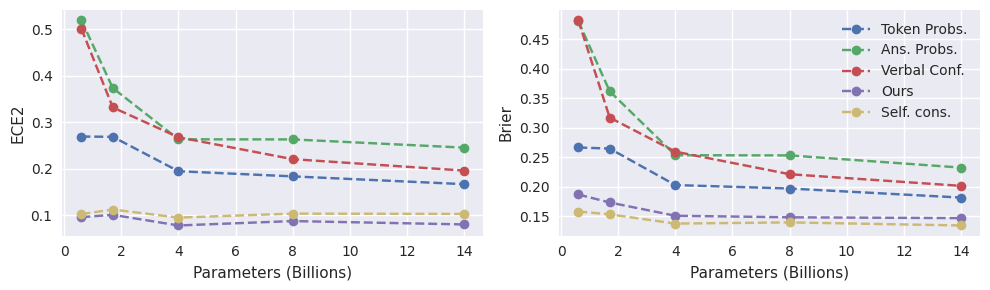

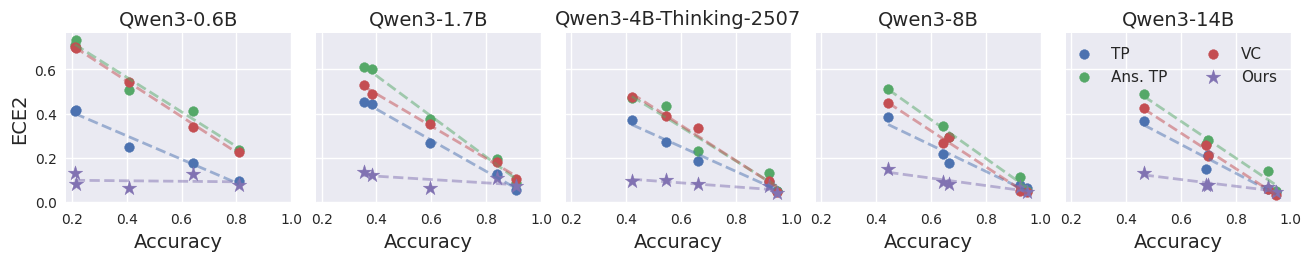

In [242]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
datasets = [
    "gsm8k",
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]
df = analyze_exps(models, datasets, plt_title="", show_models=False, show_datasets=False)

In [239]:
df.head()

,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy,seed
0,Qwen/Qwen3-0.6B,gsm8k,logprob,0.074230,0.087404,0.149404,0.471943,0.149191,0.689263,0.806344,0
1,Qwen/Qwen3-0.6B,gsm8k,ans_logprob,0.189862,0.250154,0.634738,1.869455,0.187854,0.727324,0.806344,0
2,Qwen/Qwen3-0.6B,gsm8k,oracle_sc,0.053940,0.071886,0.169434,0.419116,0.103103,0.871064,0.806344,0
3,Qwen/Qwen3-0.6B,gsm8k,ridge_clip,0.093570,0.103760,0.187311,0.858076,0.155720,0.651103,0.806344,0
4,Qwen/Qwen3-0.6B,gsm8k,split_isotonic_on_ridge,0.060409,0.066279,0.110943,0.521132,0.151273,0.650559,0.806344,0


In [180]:
show_cols = ["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]

q_models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
]
n_models = [
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
]
d_models = [
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
b_models = [
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]

m_datasets = [
    "gsm8k",
    "polymath",
]
q_datasets = [
    "trivia_qa",
    "sciq",
    "webq"
]

methods_map = {
    "logprob": "Token Probs.", 
    "ans_logprob": "Ans. Probs.", 
    "verbal_conf": "Verbal Conf.", 
    "ridge_clip": "L2 Reg.", 
    "split_isotonic_on_ridge": "Ours",
    "split_isotonic_on_ridge_nrt": "Ours",
    "oracle_sc": "Test-time SC",
    "logprob_scaled": "Supervised",
    "blackbox": "Black Box",
    "blackbox_split_isotonic_on_ridge_nrt": "Black Box",
    "question_only": "Question-only Embeds",
    "question_only_split_isotonic_on_ridge_nrt": "Question-only Embeds",
}

datasets_map = {
    "gsm8k": "GSM8K",
    "polymath": "Polymath",
    "trivia_qa": "Trivia QA",
    "sciq": "SciQ",
    "webq":"WebQ"
}

methods_order = [
    "logprob", "ans_logprob", "verbal_conf", 
    OUR_METHOD, 
    "oracle_sc", "logprob_scaled", 
    f"blackbox_{OUR_METHOD}", 
    f"question_only_{OUR_METHOD}",
    # "n_samples_5", "n_samples_20"
]


In [181]:
dataset_order = ["gsm8k", "polymath", "sciq", "trivia_qa", "webq"]

acc_table = (
    df[["Model", "Dataset", "Accuracy"]]
    .groupby(["Model", "Dataset"])["Accuracy"]
    .mean()
    .unstack("Dataset")
    .reindex(columns=dataset_order)
)

print(acc_table.reset_index().to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrrrr}
\toprule
Model & gsm8k & polymath & sciq & trivia_qa & webq \\
\midrule
Qwen/Qwen3-0.6B & 0.809 & 0.642 & 0.409 & 0.217 & 0.211 \\
Qwen/Qwen3-1.7B & 0.908 & 0.839 & 0.594 & 0.382 & 0.353 \\
Qwen/Qwen3-14B & 0.947 & 0.919 & 0.692 & 0.700 & 0.464 \\
Qwen/Qwen3-4B-Thinking-2507 & 0.949 & 0.921 & 0.662 & 0.543 & 0.420 \\
Qwen/Qwen3-8B & 0.949 & 0.922 & 0.666 & 0.642 & 0.444 \\
deepseek-ai/DeepSeek-R1-Distill-Llama-8B & 0.872 & 0.464 & NaN & NaN & NaN \\
deepseek-ai/DeepSeek-R1-Distill-Qwen-7B & 0.915 & 0.606 & NaN & NaN & NaN \\
nvidia/Nemotron-Cascade-8B-Thinking & 0.930 & 0.890 & 0.668 & 0.528 & 0.410 \\
nvidia/OpenReasoning-Nemotron-7B & 0.895 & 0.820 & NaN & NaN & NaN \\
\bottomrule
\end{tabular}



In [182]:
df[["Method", "Dataset", "ECE2", "Brier"]].groupby(["Method"])[["ECE2", "Brier"]].mean()

,ECE2,Brier
Method,,
ans_logprob,0.318387,0.296941
ans_logprob_scaled,0.069104,0.159773
blackbox_ridge_clip,0.092273,0.154172
blackbox_split_isotonic_on_ridge,0.086650,0.154464
blackbox_split_isotonic_on_ridge_nrt,0.087227,0.154810
logprob,0.215517,0.221364
logprob_scaled,0.065568,0.160519
oracle_sc,0.097957,0.138512
question_only_ridge_clip,0.104073,0.168340


In [183]:
dataset_tiled = (
    df[["Method", "Dataset", "ECE2", "Brier"]]
    .groupby(["Method", "Dataset"])[["ECE2", "Brier"]]
    .mean()
    .unstack("Dataset")
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1, level=0)
    .reindex(["ECE2", "Brier"], axis=1, level=1)
    .reindex(methods_order)
)

dataset_tiled = dataset_tiled.rename(index=methods_map)
dataset_tiled = dataset_tiled.rename(columns=datasets_map, level=0)

dataset_tiled.round(2)

Dataset              GSM8K       Polymath        SciQ       Trivia QA        \
                      ECE2 Brier     ECE2 Brier  ECE2 Brier      ECE2 Brier   
Method                                                                        
Token Probs.          0.08  0.09     0.15  0.17  0.21  0.26      0.32  0.30   
Ans. Probs.           0.11  0.09     0.26  0.20  0.33  0.34      0.48  0.47   
Verbal Conf.          0.13  0.11     0.20  0.19  0.35  0.35      0.41  0.39   
Ours                  0.06  0.08     0.09  0.13  0.07  0.21      0.09  0.18   
Test-time SC          0.06  0.07     0.10  0.10  0.11  0.20      0.08  0.15   
Supervised            0.05  0.08     0.07  0.14  0.07  0.21      0.07  0.20   
Black Box             0.06  0.08     0.10  0.12  0.07  0.21      0.09  0.19   
Question-only Embeds  0.05  0.08     0.08  0.13  0.07  0.22      0.08  0.20   

Dataset               WebQ        
                      ECE2 Brier  
Method                            
Token Probs.          0.41  0.39  
Ans. Probs.           0.56  0.54  
Verbal Conf.          0.51  0.49  
Ours                  0.13  0.23  
Test-time SC          0.17  0.23  
Supervised            0.08  0.22  
Black Box             0.13  0.23  
Question-only Embeds  0.12  0.24

In [184]:
full_fams_df = []

model_fams = [
    ("Qwen", q_models),
    ("Nemotron", n_models),
    ("DeepSeek", d_models),
    ("Big", b_models),
]

for name, fam_models in model_fams:

    # print(name)
    sub_df = df[df["Model"].isin(fam_models)]

    if name == "Nemotron":
        sub_df = df[df["Dataset"].isin(m_datasets)]
    
    fam_res_df = sub_df[show_cols].groupby(["Method"]).mean().reindex(methods_order)
    # display(fam_res_df)

    fam_res_df["Group"] = name

    full_fams_df.append(fam_res_df)

ds_fams = [
    ("Math", m_datasets),
    ("QA", q_datasets),
]

for name, fam_ds in ds_fams:

    # print(name)
    sub_df = df[df["Dataset"].isin(fam_ds)]

    fam_res_df = sub_df[show_cols].groupby(["Method"]).mean().reindex(methods_order)
    # display(fam_res_df)

    fam_res_df["Group"] = name

    full_fams_df.append(fam_res_df)

full_fams_df = pd.concat(full_fams_df).reset_index()[["Group", "Method", "ECE1", "ECE2", "MCE", "Brier","AUROC"]]

In [185]:
groups_order = ['Qwen', 'Nemotron', 'DeepSeek', 'Math', 'QA']

fams_tiled = (
    full_fams_df[["Method", "Group", "ECE2", "Brier"]]
    .groupby(["Method", "Group"])[["ECE2", "Brier"]]
    .mean()
    .unstack("Group")
    .swaplevel(0, 1, axis=1)              # columns: Dataset -> Metric
    # .sort_index(axis=1, level=0)          # sort datasets
    .reindex(groups_order, axis=1, level=0)
    .reindex(["ECE2", "Brier"], axis=1, level=1)   # metric order within each dataset
    .reindex(methods_order)               # row order
)

fams_tiled = fams_tiled.rename(index=methods_map)

fams_tiled.round(2)

Group                 Qwen       Nemotron       DeepSeek        Math        \
                      ECE2 Brier     ECE2 Brier     ECE2 Brier  ECE2 Brier   
Method                                                                       
Token Probs.          0.22  0.22     0.12  0.13     0.25  0.23  0.12  0.13   
Ans. Probs.           0.33  0.32     0.18  0.15     0.34  0.26  0.18  0.15   
Verbal Conf.          0.30  0.30     0.17  0.15     0.24  0.22  0.17  0.15   
Ours                  0.09  0.16     0.08  0.10     0.08  0.14  0.08  0.10   
Test-time SC          0.10  0.14     0.08  0.08     0.07  0.12  0.08  0.08   
Supervised            0.06  0.16     0.06  0.11     0.08  0.17  0.06  0.11   
Black Box             0.09  0.16     0.08  0.10     0.08  0.14  0.08  0.10   
Question-only Embeds  0.08  0.17     0.07  0.11     0.07  0.15  0.07  0.11   

Group                   QA        
                      ECE2 Brier  
Method                            
Token Probs.          0.31  0.32  
Ans. Probs.           0.46  0.45  
Verbal Conf.          0.42  0.41  
Ours                  0.10  0.21  
Test-time SC          0.12  0.19  
Supervised            0.07  0.21  
Black Box             0.10  0.21  
Question-only Embeds  0.09  0.22

In [186]:
print(fams_tiled.reset_index().to_latex(index=False, float_format="%.2f"))

\begin{tabular}{lrrrrrrrrrr}
\toprule
Method & \multicolumn{2}{r}{Qwen} & \multicolumn{2}{r}{Nemotron} & \multicolumn{2}{r}{DeepSeek} & \multicolumn{2}{r}{Math} & \multicolumn{2}{r}{QA} \\
 & ECE2 & Brier & ECE2 & Brier & ECE2 & Brier & ECE2 & Brier & ECE2 & Brier \\
\midrule
Token Probs. & 0.22 & 0.22 & 0.12 & 0.13 & 0.25 & 0.23 & 0.12 & 0.13 & 0.31 & 0.32 \\
Ans. Probs. & 0.33 & 0.32 & 0.18 & 0.15 & 0.34 & 0.26 & 0.18 & 0.15 & 0.46 & 0.45 \\
Verbal Conf. & 0.30 & 0.30 & 0.17 & 0.15 & 0.24 & 0.22 & 0.17 & 0.15 & 0.42 & 0.41 \\
Ours & 0.09 & 0.16 & 0.08 & 0.10 & 0.08 & 0.14 & 0.08 & 0.10 & 0.10 & 0.21 \\
Test-time SC & 0.10 & 0.14 & 0.08 & 0.08 & 0.07 & 0.12 & 0.08 & 0.08 & 0.12 & 0.19 \\
Supervised & 0.06 & 0.16 & 0.06 & 0.11 & 0.08 & 0.17 & 0.06 & 0.11 & 0.07 & 0.21 \\
Black Box & 0.09 & 0.16 & 0.08 & 0.10 & 0.08 & 0.14 & 0.08 & 0.10 & 0.10 & 0.21 \\
Question-only Embeds & 0.08 & 0.17 & 0.07 & 0.11 & 0.07 & 0.15 & 0.07 & 0.11 & 0.09 & 0.22 \\
\bottomrule
\end{tabular}



In [194]:
groups_order = ['Qwen', 'Nemotron', 'DeepSeek', 'Math', 'QA']
target_metric = "ECE2"

fams_tiled = (
    full_fams_df[["Method", "Group", target_metric]]
    .groupby(["Method", "Group"])[[target_metric]]
    .mean()
    .unstack("Group")
    .swaplevel(0, 1, axis=1)              # columns: Dataset -> Metric
    # .sort_index(axis=1, level=0)          # sort datasets
    .reindex(groups_order, axis=1, level=0)
    .reindex([target_metric], axis=1, level=1)   # metric order within each dataset
    .reindex(methods_order)               # row order
)

fams_tiled = fams_tiled.rename(index=methods_map)

print(fams_tiled.reset_index().to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lrrrrr}
\toprule
Method & Qwen & Nemotron & DeepSeek & Math & QA \\
 & ECE2 & ECE2 & ECE2 & ECE2 & ECE2 \\
\midrule
Token Probs. & 0.2168 & 0.1161 & 0.2502 & 0.1161 & 0.3149 \\
Ans. Probs. & 0.3331 & 0.1817 & 0.3363 & 0.1817 & 0.4551 \\
Verbal Conf. & 0.3036 & 0.1653 & 0.2427 & 0.1653 & 0.4206 \\
Ours & 0.0888 & 0.0753 & 0.0763 & 0.0753 & 0.0973 \\
Test-time SC & 0.1035 & 0.0775 & 0.0669 & 0.0775 & 0.1184 \\
Supervised & 0.0634 & 0.0577 & 0.0833 & 0.0577 & 0.0735 \\
Black Box & 0.0901 & 0.0774 & 0.0771 & 0.0774 & 0.0970 \\
Question-only Embeds & 0.0810 & 0.0663 & 0.0693 & 0.0663 & 0.0892 \\
\bottomrule
\end{tabular}



In [195]:
groups_order = ['Qwen', 'Nemotron', 'DeepSeek', 'Math', 'QA']
target_metric = "Brier"

fams_tiled = (
    full_fams_df[["Method", "Group", target_metric]]
    .groupby(["Method", "Group"])[[target_metric]]
    .mean()
    .unstack("Group")
    .swaplevel(0, 1, axis=1)              # columns: Dataset -> Metric
    # .sort_index(axis=1, level=0)          # sort datasets
    .reindex(groups_order, axis=1, level=0)
    .reindex([target_metric], axis=1, level=1)   # metric order within each dataset
    .reindex(methods_order)               # row order
)

fams_tiled = fams_tiled.rename(index=methods_map)

print(fams_tiled.reset_index().to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lrrrrr}
\toprule
Method & Qwen & Nemotron & DeepSeek & Math & QA \\
 & Brier & Brier & Brier & Brier & Brier \\
\midrule
Token Probs. & 0.2225 & 0.1275 & 0.2341 & 0.1275 & 0.3152 \\
Ans. Probs. & 0.3162 & 0.1470 & 0.2589 & 0.1470 & 0.4468 \\
Verbal Conf. & 0.2962 & 0.1501 & 0.2218 & 0.1501 & 0.4096 \\
Ours & 0.1612 & 0.1023 & 0.1396 & 0.1023 & 0.2079 \\
Test-time SC & 0.1446 & 0.0831 & 0.1157 & 0.0831 & 0.1939 \\
Supervised & 0.1614 & 0.1099 & 0.1702 & 0.1099 & 0.2111 \\
Black Box & 0.1600 & 0.1000 & 0.1390 & 0.1000 & 0.2096 \\
Question-only Embeds & 0.1692 & 0.1088 & 0.1461 & 0.1088 & 0.2193 \\
\bottomrule
\end{tabular}



In [187]:
comp_methods_order = ["logprob", "ans_logprob", "verbal_conf", OUR_METHOD]
order_map = {item: i for i, item in enumerate(comp_methods_order)}

full_model_df = []
for model in models:
    model_df = df[(df["Model"] == model) & (df["Method"].isin(comp_methods_order))]
    model_summ = model_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean().reset_index()
    model_summ["Model"] = model.split("/")[-1]
    model_summ = model_summ.sort_values(by='Method', key=lambda s: s.map(order_map))
    full_model_df.append(model_summ)

full_model_df = pd.concat(full_model_df)
full_model_df = full_model_df[["Model", "Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]]

method_names = [methods_map[method] for method in full_model_df["Method"].tolist()]
full_model_df["Method"] = method_names

In [188]:
print(full_model_df[["Model", "Method", "ECE1", "ECE2", "MCE"]].to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrrr}
\toprule
Model & Method & ECE1 & ECE2 & MCE \\
\midrule
Qwen3-0.6B & Token Probs. & 0.256 & 0.269 & 0.374 \\
Qwen3-0.6B & Ans. Probs. & 0.493 & 0.519 & 0.731 \\
Qwen3-0.6B & Verbal Conf. & 0.476 & 0.501 & 0.628 \\
Qwen3-0.6B & Ours & 0.081 & 0.096 & 0.226 \\
Qwen3-1.7B & Token Probs. & 0.247 & 0.269 & 0.395 \\
Qwen3-1.7B & Ans. Probs. & 0.362 & 0.374 & 0.510 \\
Qwen3-1.7B & Verbal Conf. & 0.306 & 0.332 & 0.470 \\
Qwen3-1.7B & Ours & 0.081 & 0.101 & 0.228 \\
Qwen3-4B-Thinking-2507 & Token Probs. & 0.176 & 0.195 & 0.302 \\
Qwen3-4B-Thinking-2507 & Ans. Probs. & 0.235 & 0.263 & 0.445 \\
Qwen3-4B-Thinking-2507 & Verbal Conf. & 0.251 & 0.268 & 0.416 \\
Qwen3-4B-Thinking-2507 & Ours & 0.063 & 0.078 & 0.180 \\
Qwen3-8B & Token Probs. & 0.165 & 0.184 & 0.285 \\
Qwen3-8B & Ans. Probs. & 0.250 & 0.263 & 0.389 \\
Qwen3-8B & Verbal Conf. & 0.204 & 0.221 & 0.344 \\
Qwen3-8B & Ours & 0.071 & 0.088 & 0.199 \\
Qwen3-14B & Token Probs. & 0.145 & 0.167 & 0.302 \\
Qwen3-14B & Ans. 

In [189]:
print(full_model_df[["Model", "Method", "Brier", "AUROC"]].to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrr}
\toprule
Model & Method & Brier & AUROC \\
\midrule
Qwen3-0.6B & Token Probs. & 0.266 & 0.640 \\
Qwen3-0.6B & Ans. Probs. & 0.481 & 0.621 \\
Qwen3-0.6B & Verbal Conf. & 0.482 & 0.592 \\
Qwen3-0.6B & Ours & 0.187 & 0.654 \\
Qwen3-1.7B & Token Probs. & 0.265 & 0.692 \\
Qwen3-1.7B & Ans. Probs. & 0.362 & 0.584 \\
Qwen3-1.7B & Verbal Conf. & 0.317 & 0.637 \\
Qwen3-1.7B & Ours & 0.173 & 0.699 \\
Qwen3-4B-Thinking-2507 & Token Probs. & 0.203 & 0.661 \\
Qwen3-4B-Thinking-2507 & Ans. Probs. & 0.253 & 0.596 \\
Qwen3-4B-Thinking-2507 & Verbal Conf. & 0.259 & 0.621 \\
Qwen3-4B-Thinking-2507 & Ours & 0.151 & 0.705 \\
Qwen3-8B & Token Probs. & 0.197 & 0.699 \\
Qwen3-8B & Ans. Probs. & 0.253 & 0.618 \\
Qwen3-8B & Verbal Conf. & 0.221 & 0.684 \\
Qwen3-8B & Ours & 0.148 & 0.715 \\
Qwen3-14B & Token Probs. & 0.182 & 0.708 \\
Qwen3-14B & Ans. Probs. & 0.232 & 0.641 \\
Qwen3-14B & Verbal Conf. & 0.202 & 0.671 \\
Qwen3-14B & Ours & 0.147 & 0.698 \\
OpenReasoning-Nemotron-7B & Token P

In [191]:
comp_methods_order = [
    "logprob", 
    "ans_logprob", 
    "verbal_conf", 
    OUR_METHOD, 
    "oracle_sc",
    "logprob_scaled",
    f"question_only_{OUR_METHOD}",
    f"blackbox_{OUR_METHOD}",
]
order_map = {item: i for i, item in enumerate(comp_methods_order)}

full_dataset_df = []
for dataset in datasets:
    dataset_df = df[(df["Dataset"] == dataset) & (df["Method"].isin(comp_methods_order))]
    dataset_summ = dataset_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean().reset_index()
    dataset_summ["Dataset"] = DATASETS_MAP[dataset]
    dataset_summ = dataset_summ.sort_values(by='Method', key=lambda s: s.map(order_map))
    full_dataset_df.append(dataset_summ)

full_dataset_df = pd.concat(full_dataset_df)
full_dataset_df = full_dataset_df[["Dataset", "Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]]

method_names = [methods_map[method] for method in full_dataset_df["Method"].tolist()]
full_dataset_df["Method"] = method_names

print(full_dataset_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrrrrr}
\toprule
Dataset & Method & ECE1 & ECE2 & MCE & Brier & AUROC \\
\midrule
GSM8K & Token Probs. & 0.075 & 0.083 & 0.135 & 0.086 & 0.655 \\
GSM8K & Ans. Probs. & 0.089 & 0.107 & 0.221 & 0.090 & 0.615 \\
GSM8K & Verbal Conf. & 0.096 & 0.130 & 0.310 & 0.106 & 0.638 \\
GSM8K & Ours & 0.045 & 0.058 & 0.133 & 0.078 & 0.694 \\
GSM8K & Test-time SC & 0.044 & 0.057 & 0.139 & 0.065 & 0.798 \\
GSM8K & Supervised & 0.038 & 0.047 & 0.101 & 0.079 & 0.642 \\
GSM8K & Question-only Embeds & 0.045 & 0.051 & 0.101 & 0.083 & 0.576 \\
GSM8K & Black Box & 0.045 & 0.057 & 0.130 & 0.077 & 0.689 \\
Polymath & Token Probs. & 0.130 & 0.149 & 0.251 & 0.169 & 0.661 \\
Polymath & Ans. Probs. & 0.205 & 0.256 & 0.538 & 0.204 & 0.735 \\
Polymath & Verbal Conf. & 0.175 & 0.200 & 0.350 & 0.194 & 0.631 \\
Polymath & Ours & 0.071 & 0.093 & 0.209 & 0.126 & 0.767 \\
Polymath & Test-time SC & 0.067 & 0.098 & 0.235 & 0.101 & 0.876 \\
Polymath & Supervised & 0.054 & 0.068 & 0.142 & 0.141 & 0.665 \\
Poly